In [3]:
from tensorflow import keras

In [4]:
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) =\
   keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [45]:
 # CNN 적용
model = keras.Sequential()
model.add(keras.layers.Input(shape=(227,227,3)))
model.add(keras.layers.Conv2D(96, kernel_size=11, strides=4,activation='relu', padding='valid'))
model.add(keras.layers.MaxPooling2D(3,strides=2))
model.add(keras.layers.Conv2D(256, kernel_size=5, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(3,strides=2))
model.add(keras.layers.Conv2D(384, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.Conv2D(384, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(3,strides=2))

In [46]:
# DNN 적용
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(4096, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(4096, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1000, activation='softmax'))

In [47]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,378,344 (237.95 MB)

 Trainable params: 62,378,344 (237.95 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
es = keras.callbacks.EarlyStopping(patience=2,
                             restore_best_weights=True)

history = model.fit(train_scaled, train_target, epochs=100, verbose=1,
        validation_data=(val_scaled, val_target),
                   callbacks=[cb,es])
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


Epoch 1/100


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'conv2d_18' is incompatible with the layer: expected axis -1 of input shape to have value 3, but received input with shape (32, 28, 28, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 28, 28, 1), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

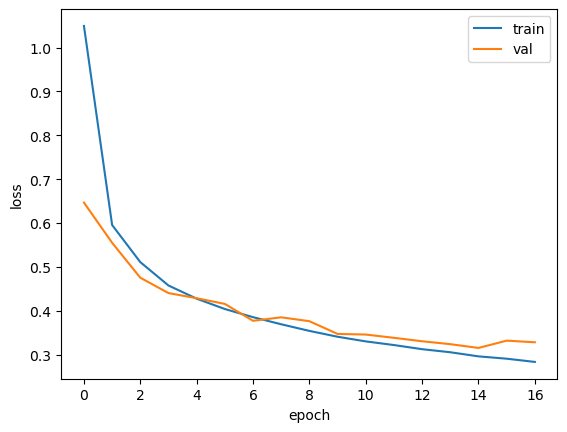

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [11]:
print(es.stopped_epoch)

16


In [12]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8844 - loss: 0.3154 


[0.31538695096969604, 0.8844166398048401]

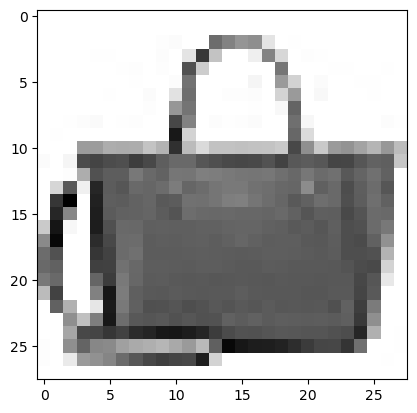

In [13]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()


In [14]:
preds = model.predict(val_scaled[0:1])
print(preds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[[7.1030177e-06 7.3852482e-07 1.0019622e-05 1.5513382e-05 9.1501512e-05
  9.6907138e-07 6.6235316e-06 1.1667967e-05 9.9985516e-01 5.6442371e-07]]


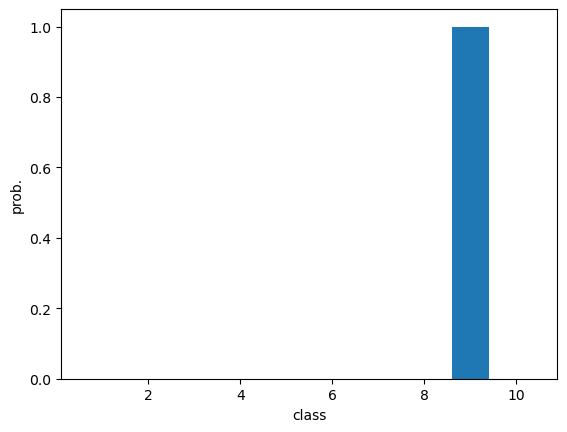

In [15]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()


In [16]:
classes = ["티셔츠", "바지", "스웨터" , "드레스", "코트"," 샌달" , "셔츠" , "스니커즈","가방", "앵클부츠"]
import numpy as np
print(classes[np.argmax(preds)])


가방


In [17]:
test_scaled = test_input.reshape(-1, 28, 28, 1) /255

In [18]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8794 - loss: 0.3313   


[0.3313436210155487, 0.8794000148773193]

In [ ]:
model.layers

In [19]:
cb = keras.callbacks.ModelCheckpoint('lenet5-model.keras', save_best_only=True)